# TP: Régression logistique et `scikit-learn` 



Dans ce premier TP, nous mettons en oeuvre un modèle de **régression logistique** pour la prédiction de labels binaires $y \in \{0,1\}$. On rappelle que la régression logistique repose sur une modélisation probabiliste, et donc plutôt que de prédire simplement 0 ou 1, on construit un estimateur $\hat P(y=1|x)$ de la probabilité $\mathbf{P}(y=1|x)$ et on définit un classifieur comme
$$\hat y (x_{new}) = \begin{cases} 1 & \text{si } \hat P(y=1|x_{new}) \geq t, \\ 0 & \text{sinon}\end{cases}$$
pour un seuil $t\in(0,1)$ donné. Par défaut, si les labels jouent un rôle symmetrique, $t=1/2$.

# Le jeu de données

Les données utilisées dans ce TP proviennent d'un jeu de données classique qui s'appelle *Census Income dataset* (également connu sous le nom de *Adult Income* et disponible sur le site [https://archive.ics.uci.edu/ml/datasets/adult](https://archive.ics.uci.edu/ml/datasets/adult)).

Ce dataset a été extrait par Barry Becker du recensement américain de 1994 et est souvent utilisé pour des tâches de classification binaire, où l'objectif est de **prédire si un individu gagne plus ou moins de $50\,000$ dollars par an**, en se basant sur les caractéristiques démographiques et professionnelles disponibles. Les **caractéristiques sont qualitatives et quantitatives** et incluent l'âge, le niveau d'éducation, le statut matrimonial, la profession, le pays d'origine, le sexe, le capital investi, le nombre d'heures de travail par semaine, etc.

Le fichier `data/adult_clean.csv` a été obtenu en nettoyant les fichiers publics (voir le notebook `day1_preparation_data.ipynb`): on a retiré les données manquantes et les doublons. 

On utilise le module `pandas` qui est une bibliothèque open-source populaire en Python, largement utilisée pour la manipulation et l'analyse des données. Ce module fournit des structures de données flexibles et performantes: 
- les **DataFrames** qui sont similaires aux tables de base de données ou aux feuilles de calcul Excel
- les **Series** qui sont des tableaux unidimensionnels avec étiquettes.

In [1]:
import numpy as np
import pandas as pd

In [2]:
import warnings 
warnings.simplefilter(action='ignore', category=FutureWarning)

## Exercice : Chargement 

- Importer les données du fichier `data/adult_clean.csv` sous forme d'un `DataFrame` pandas que l'on nomme `dataset`. 
- Visualiser les premières lignes de `dataset`, noter le nombre de caractéristiques (et leurs noms) et le nom de la variable à prédire.
- Quel est le nombre total de données (de lignes) du `dataset`, et la proportion de données `<=50K` et `>50K`?

In [3]:
# on visualise les premières lignes du fichier pour voir la structure
# ici le format est classique: la "," est le séparateur et la première ligne contient le nom des colonnes
filename = "data/adult_clean.csv"
with open(filename, 'r') as f:
    for line, k  in zip(f, range(5)): 
        print(line.strip())

age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K


In [4]:
# on crée l'objet dataset via l'appel de la fonction `read_csv` du module pandas
dataset = pd.read_csv(filename)

In [5]:
# on visualise les 5 premières lignes du `dataset`
dataset.head(5)

,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [6]:
# on utilise la méthode `value_counts` pour obtenir des informations sur les données à prédire 
dataset["class"].value_counts()

class
<=50K    29265
>50K      9975
Name: count, dtype: int64

In [7]:
print([m for m in dir(dataset) if m.startswith('_') == False])

['T', 'abs', 'add', 'add_prefix', 'add_suffix', 'age', 'agg', 'aggregate', 'align', 'all', 'any', 'apply', 'asfreq', 'asof', 'assign', 'astype', 'at', 'at_time', 'attrs', 'axes', 'between_time', 'bfill', 'boxplot', 'class', 'clip', 'columns', 'combine', 'combine_first', 'compare', 'convert_dtypes', 'copy', 'corr', 'corrwith', 'count', 'cov', 'cummax', 'cummin', 'cumprod', 'cumsum', 'describe', 'diff', 'div', 'divide', 'dot', 'drop', 'drop_duplicates', 'droplevel', 'dropna', 'dtypes', 'duplicated', 'education', 'empty', 'eq', 'equals', 'eval', 'ewm', 'expanding', 'explode', 'ffill', 'fillna', 'filter', 'first_valid_index', 'flags', 'floordiv', 'from_arrow', 'from_dict', 'from_records', 'ge', 'get', 'groupby', 'gt', 'head', 'hist', 'iat', 'idxmax', 'idxmin', 'iloc', 'index', 'infer_objects', 'info', 'insert', 'interpolate', 'isetitem', 'isin', 'isna', 'isnull', 'items', 'iterrows', 'itertuples', 'join', 'keys', 'kurt', 'kurtosis', 'last_valid_index', 'le', 'loc', 'lt', 'map', 'mask', 'ma

## Exercice : Exploration, visualisation 

Familiarisez-vous avec les données.

- Calculer quelques statistiques descriptives (à l'aide de `shape`, `dtypes`, `describe`, `value_counts`).
- Visualiser quelques caractéristiques en fonction des 2 groupes `<=50K` et `>50K`.

Pour tracer des graphiques on pourra utiliser les librairies `matplotlib` et `seaborn` :

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

On pourra utiliser les fonctions suivantes :
- `sns.scatterplot` pour des nuages des points
- `sns.histplot` pour des histogrammes et des diagrammes en bâtons

**Exemple** :

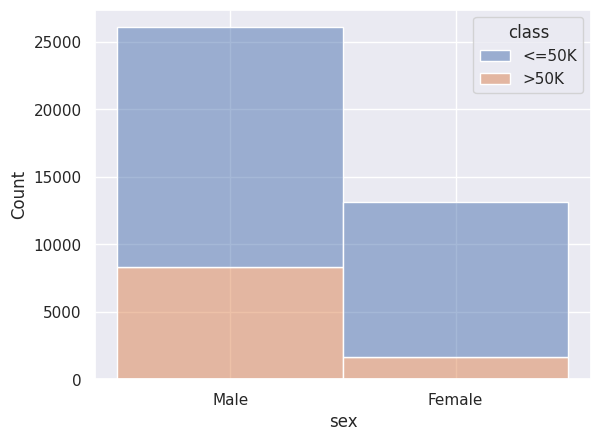

In [9]:
ax = sns.histplot(data=dataset, x="sex", hue="class", 
                  multiple="stack", alpha=0.5, discrete=True)

In [10]:
dataset.shape

(39240, 13)

In [11]:
dataset.describe()

,age,capital-gain,capital-loss,hours-per-week
count,39240.000000,39240.000000,39240.000000,39240.000000
mean,39.309225,1253.314246,101.261340,41.206091
std,13.298041,7993.997264,431.434412,12.458021
min,17.000000,0.000000,0.000000,1.000000
25%,29.000000,0.000000,0.000000,40.000000
50%,38.000000,0.000000,0.000000,40.000000
75%,48.000000,0.000000,0.000000,45.000000
max,90.000000,99999.000000,4356.000000,99.000000


In [12]:
dataset.describe(include='str')

,workclass,education,marital-status,occupation,relationship,race,sex,native-country,class
count,39240,39240,39240,39240,39240,39240,39240,39240,39240
unique,7,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,27717,12003,17947,5516,15645,33064,26097,35340,29265


In [13]:
dataset["sex"].value_counts()

sex
Male      26097
Female    13143
Name: count, dtype: int64

In [14]:
dataset["race"].value_counts()

race
White                 33064
Black                  4089
Asian-Pac-Islander     1299
Amer-Indian-Eskimo      435
Other                   353
Name: count, dtype: int64

In [15]:
dataset["workclass"].unique()

<StringArray>
[       'State-gov', 'Self-emp-not-inc',          'Private',
      'Federal-gov',        'Local-gov',     'Self-emp-inc',
      'Without-pay']
Length: 7, dtype: str

<Axes: xlabel='age', ylabel='Count'>

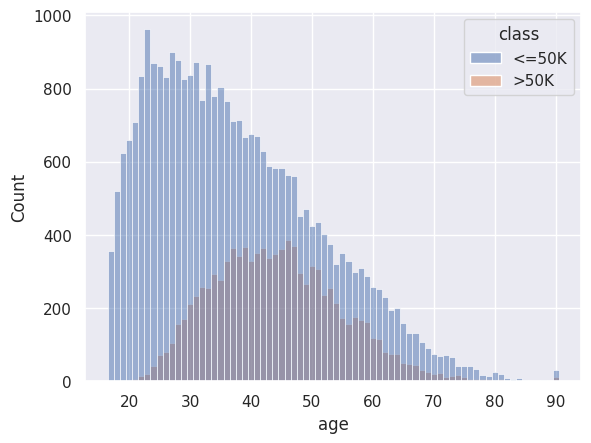

In [16]:
sns.histplot(data=dataset, x="age", 
             hue="class", 
             multiple="layer", 
             alpha=0.5, 
             discrete=True
            )

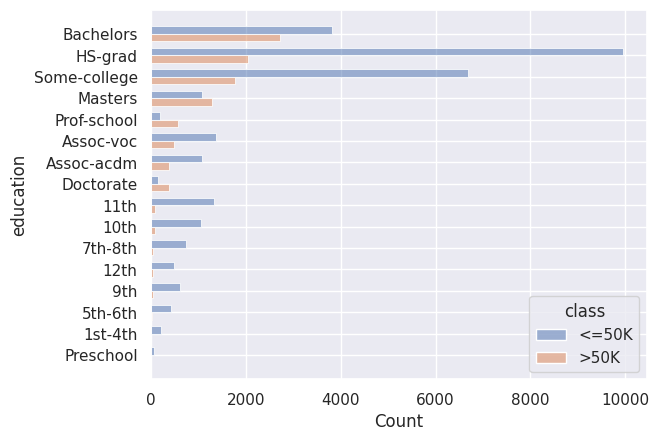

In [17]:
order = (
    dataset.loc[dataset["class"] == ">50K", "education"]
    .value_counts()
    .index
)

dataset["education"] = pd.Categorical(
    dataset["education"],
    categories=order,
    ordered=True
)

ax = sns.histplot(data=dataset, y="education", hue="class", 
                  multiple="dodge", shrink=0.7,
                  alpha=0.5, discrete=True)

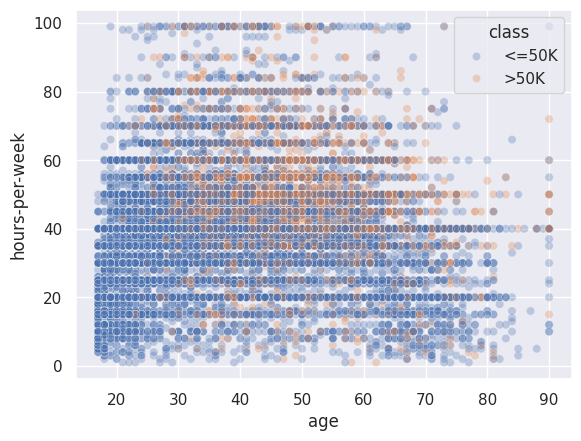

In [18]:
ax = sns.scatterplot(data=dataset, x="age", y="hours-per-week",
                     hue="class", alpha=0.3)

## Exercice : Pré-traitement des données

On ne travaille que très rarement sur des donnnées brutes. 

Pour des  **variables quantitatives**, il est important de les  **standardiser** (centrer et réduire) afin de les ramener à  des échelles comparables. Cela diminue également les problèmes numériques. 

Pour une **variable qualitative** ou **catégorielle**, il n'y a en général pas  d'ordre naturel de ses modalités. Donc il ne faut pas bêtement remplacer des catégories *A*, *B*, *C*,... par 1, 2, 3,... Le problème est que dans un modèle de régression, on va calculer par exemple des moyennes sur ces valeurs, mais en général *B* n'est pas la moyenne de *A* et *C* (alors que c'est le cas pour la valeur 2 par rapport à 1 et 3). Il nous faut alors un encodage qui est invariant à l'ordre des modalités. On utilise  le **one-hot encoding** qui consiste à transformer une variable qualitative en plusieurs variables binaires dites **dummies**. Une variable avec K modalités est transformée en K-1 variables binaires. Chacune de ces variables binaires indique pour une catégorie spécifiée si la variable observée est égale à cette catégorie ou pas. Il suffit de K-1 variables binaires pour encoder K catégories, car l'information sur la K-ième catégorie peut être déduite des K-1 autres variables binaires. Donc, si on utilisait K variables binaires, on introduirait des corrélations entre les colonnes, ce qu'il faut éviter dans un cadre de régression.

- Séparer les données en 3 dataframes qu'on nomme :

    - `quantitative`: dataframe avec toutes les covariables quantitatives
    - `qualitative`: dataframe avec toutes les covariables qualitatives
    - `category` : pour les labels observés `class`

En vue de la régression logistique on effectue le pré-traitement suivant: définir les variables 
- `labels` en remplaçant les classes `<=50K` et `>50K` par les valeurs numériques 0 et 1
- `quantitative_norm` obtenu en renormalisant le dataset `quantitative`
- `qualitative_enc` obtenu par l'appel de `get_dummies` du module `pandas` sur le dataset `qualitative`
- `standard_data` obtenu en regroupant `quantitative_norm` et `qualitative_enc`

In [19]:
quant_columns = [ "age", "capital-gain", "capital-loss", "hours-per-week" ]
quali_columns = [ "workclass", "education", "marital-status", "occupation", 
                  "relationship", "race", "sex", "native-country" ]
quantitative = dataset[quant_columns]
qualitative = dataset[quali_columns]
category = dataset["class"]

In [20]:
labels = category.map({ '<=50K': 0, '>50K': 1 }) 

In [21]:
quantitative_norm = (quantitative - quantitative.mean()) / quantitative.std()
quantitative_norm.describe()

,age,capital-gain,capital-loss,hours-per-week
count,3.924000e+04,3.924000e+04,3.924000e+04,3.924000e+04
mean,1.448609e-16,7.243045e-18,-2.100483e-17,4.345827e-17
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.677632e+00,-1.567819e-01,-2.347085e-01,-3.227326e+00
25%,-7.752439e-01,-1.567819e-01,-2.347085e-01,-9.681239e-02
50%,-9.845249e-02,-1.567819e-01,-2.347085e-01,-9.681239e-02
75%,6.535380e-01,-1.567819e-01,-2.347085e-01,3.045355e-01
max,3.811898e+00,1.235248e+01,9.861844e+00,4.639092e+00


In [22]:
qualitative_enc = pd.get_dummies(qualitative)
qualitative_enc.describe()

,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,education_Bachelors,education_HS-grad,education_Some-college,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
count,39240,39240,39240,39240,39240,39240,39240,39240,39240,39240,...,39240,39240,39240,39240,39240,39240,39240,39240,39240,39240
unique,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
top,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
freq,37869,36265,27717,37645,35571,37348,39219,32718,27237,30783,...,39178,39065,39220,39139,39185,39211,39214,35340,39157,39217


In [23]:
standard_data = pd.concat([quantitative_norm, qualitative_enc], axis=1)

# Régression logistique

Le but de ce TP est de fitter un modèle de régression logistique à ces données afin de prédire le label (0 pour `<=50K` ou 1 pour `>50K`) pour des  nouveaux individus à partir de leurs caractéristiques. Nous commençons par le modèle simple qui prend en compte toutes les variables.


## Exercice : Définition du modèle et estimation

- Utiliser la fonction `LogisticRegression` de `sklearn.linear_model` pour effectuer une régression logistique simple (i.e. sans pénalisation). L'estimation des paramètres se fait avec la fonction `fit`.
- Visualiser les coefficients estimés (intercept et variables).

In [24]:
from sklearn.linear_model import LogisticRegression

# Définition du modèle de régression logistique : sans pénalisation 
model = LogisticRegression(penalty=None, max_iter=1000)
# sans l'option max_iter, on peut avoir un nb max d'itérations insuffisant pour atteindre la convergence

# On estime les paramètres de ce modèle sur les données 
model.fit(standard_data, labels)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [25]:
print([m for m in dir(model) if m.startswith('_') == False])

['C', 'class_weight', 'classes_', 'coef_', 'decision_function', 'densify', 'dual', 'feature_names_in_', 'fit', 'fit_intercept', 'get_metadata_routing', 'get_params', 'intercept_', 'intercept_scaling', 'l1_ratio', 'max_iter', 'n_features_in_', 'n_iter_', 'n_jobs', 'penalty', 'predict', 'predict_log_proba', 'predict_proba', 'random_state', 'score', 'set_fit_request', 'set_params', 'set_score_request', 'solver', 'sparsify', 'tol', 'verbose', 'warm_start']


## Exercice : Prédiction

La méthode `predict_proba` renvoie 2 colonnes: la première est la probabilité, conditionnellement aux caractéristiques de chaque individu, d'être dans la catégorie `<50K` (label 0, négatif) et la seconde la probabilité, conditionnellement aux caractéristiques de chaque individu, d'être dans la catégorie  `>=50K` (label 1, positif). A partir de ces probabilités on peut "décider" en fixant un seuil $t \in [0,1]$ d'être ou non dans une des 2 catégories en utilisant le classifieur construit à partir de ces probabilités : 
$$\hat y (x_{new}) = \begin{cases} 1 & \text{si } \hat P(y=1|x_{new}) \geq t, \\ 0 & \text{sinon}\end{cases}$$

- Calculer $\hat P(y=1|x)$, les probabilités que `>50K` pour chaque individu $x$ (`predict_proba()`) et les prédictions $\hat y(x)$ (`predict()`) que l'on obtient par seuillage des probabilités au seuil de $t = 1/2$.
- Comparer le nombre moyen de positifs prédits par rapport à celui connu dans `labels`. 
- Visualiser la distribution des probabilités prédites.
- Faire varier le seuil $t \in [0,1]$.

In [26]:
seuil = 0.5
pred_prob = model.predict_proba(standard_data)

In [27]:
pred = pred_prob[:,1] > seuil

pred.mean()

np.float64(0.21009174311926607)

# Echantillons : apprentissage et test 

Utiliser l'intégralité du jeu de données pour entrainer le modèle comme nous l'avons fait n'est pas la bonne démarche à suivre, puisque nous avons testé le modèle sur les mêmes données qui l'ont entrainé, alors qu'il faudrait le tester sur des nouvelles données. 

C'est pour cela qu'il faut séparer le jeu de données en deux, un jeu d'apprentissage (TRAIN) et un de test (TEST).

On rappelle que la modélisation se fait en trois temps :
- on sépare les données : TRAIN / TEST
- on apprend le modèle sur TRAIN
- on évalue la performance du modèle appris sur TEST

On coupe les données de façon aléatoire en deux groupes. 
Le plus souvent, on les sépare en 80% pour l'apprentissage et 20% pour le test. D'autres pourcentages courants sont 67-33 ou 50-50.
On   utilise la  fonction `train_test_split` du package `sklearn.model_selection` pour séparer aléatoirement les données. 

Même si le split est aléatoire, on souhaite que les deux échantillons soient tous les deux représentatifs du problème. En particulier, on voudrait qu'ils contiennent le même pourcentage de labels 0 et 1, ce qui est notamment important quand  les labels ne sont pas équilibrés (pas 50-50).

Ici, la proportion de 1 (individus qui sont dans la catégorie `>50K`) est d'environ 0.25 (le vérifier!).

Si le taux n'est pas très élevé, une coupe totalement aléatoire des données risque de produire des sous-échantillons où l'un des deux ne contient que peu de labels qui valent 1. Cela peut être problématique pour l'apprentissage du modèle comme pour l'évaluation de la méthode.

En pratique, dans des problèmes de classification, on force alors la même répartition des labels dans les deux échantillons TRAIN et TEST, via l'option `stratify`.

## Exercice : Création des échantillons 

Utiliser la fonction `train_test_split` du module `scikit-learn` pour créer à partir de nos données `quantitative_norm`, `qualitative_enc` et `labels` les 4 variables suivantes: 
- `x_train` et `y_train` qui contiennent 80% du jeu de données pour l'apprentissage du modèle de régression logistique 
- `x_test` et `y_test` qui contiennent les 20% restants pour le test.

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
x_train, x_test, y_train, y_test = train_test_split(standard_data, labels,test_size=0.2, stratify=labels)

# Régression logistique avec séparation des données en train et test

Reprendre la regression logistique vue au point précédent, avec les bons jeu de données pour l'entrainement et le test.

## Exercice : Création du modèle et estimation

- Utiliser la fonction `LogisticRegression` de `sklearn.linear_model` pour effectuer une régression logistique simple (i.e. sans pénalisation). Fitter le modèle sur les données `train`. 
- Visualiser les coefficients estimés (intercept et variables).

In [30]:
model = LogisticRegression(penalty=None, max_iter=1000)



In [31]:
model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [32]:
model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [ ]:
model.intercept_


## Exercice : Prédiction

- Sur le jeu `test`, calculer $\hat P(y=1|x)$, les probabilités que `>50K` pour chaque individu $x$ (`predict_proba()`) et les prédictions $\hat y(x)$ (`predict()`) que l'on obtient par seuillage des probabilités au seuil de $t = 1/2$.
- Comparer le nombre moyen de positifs prédits par rapport à celui connu dans `y_test`. 
- Visualiser la distribution des probabilités prédites.
- Faire varier le seuil $t \in [0,1]$.

In [33]:
pred_proba = model.predict_proba(x_test)

In [35]:
pred_proba[:,1]

array([0.25721497, 0.14876332, 0.1473556 , ..., 0.71888075, 0.38553364,
       0.39152893], shape=(7848,))

In [36]:
seuil = 0.5
pred  = pred_proba[:,1] > seuil

In [41]:
print(pred.mean())
print(y_test.mean())

0.2057849133537207
0.25420489296636084


# Mesures de qualité du classifieur 

Le module `metrics` de `scikit-learn` contient plusieurs fonctions qui permettent d'évaluer la qualité des prédictions d'un modèle. Ces métriques sont détaillées dans les sections sur les métriques de classification, les métriques de classement multi-label, les métriques de régression et les métriques de clustering.

In [42]:
import sklearn.metrics as metrics
print(dir(metrics))

['ConfusionMatrixDisplay', 'DetCurveDisplay', 'DistanceMetric', 'PrecisionRecallDisplay', 'PredictionErrorDisplay', 'RocCurveDisplay', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_base', '_classification', '_dist_metrics', '_pairwise_distances_reduction', '_pairwise_fast', '_plot', '_ranking', '_regression', '_scorer', 'accuracy_score', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'auc', 'average_precision_score', 'balanced_accuracy_score', 'brier_score_loss', 'calinski_harabasz_score', 'check_scoring', 'class_likelihood_ratios', 'classification_report', 'cluster', 'cohen_kappa_score', 'completeness_score', 'confusion_matrix', 'confusion_matrix_at_thresholds', 'consensus_score', 'coverage_error', 'd2_absolute_error_score', 'd2_brier_score', 'd2_log_loss_score', 'd2_pinball_score', 'd2_tweedie_score', 'davies_bouldin_score', 'dcg_score', 'det_curve', 'euclidean_distances', 'explained_variance_s

## Erreurs de classification 
Pour chaque individu $i$ de caractéristiques $x_i$ dans l'échantillon, nous avons : 
- un vrai label/valeur $y_i$
- un label/valeur prédit $\hat y_i$

Deux types d'erreur peuvent se produire :
1. Prédire $\hat y_i =1$ alors que $y_i=0$ (faux positif/false positive, FP)
2. Prédire $\hat y_i =0$ alors que $y_i=1$ (faux négatif, false negative, FN)

Dans un contexte pratique, ces deux erreurs ne sont pas symétriques, parce qu'une erreur peut porter à des  effets plus négatifs que l'autre. En général, les labels sont choisis de sorte à être moins tolérants aux faux positifs qu'aux faux négatifs, pensons par exemple aux tests de grossesse, ou aux procès en justice. 


### Exercice : Accuracy score (ou taux de bonnes classifications)

Le taux de bonnes classifications (_accuracy score_) est la mesure de performance qui représente la proportion d'observations correctement classées par le modèle parmi l'ensemble total des observations. Ce taux est un pourcentage, où une valeur de 100% signifie que toutes les prédictions du modèle sont correctes.

- Implémenter à la main (en `numpy`) le calcul de ce score pour les données de test.
- Obtenir ce score via l'appel de `accuracy_score` du module `sklearn.metrics` et via la méthode `score` de l'objet `model`.
- Comparer ce score à un estimateur trivial qui consiste à toujours renvoyer la classe la plus fréquente.

In [49]:
y_predicted = model.predict(x_test)
accuracy = np.mean(y_predicted == y_test)
print(f"Accuracy: {accuracy:.3f}")

print("Accuracy model", round(model.score(x_test, y_test),3))

Accuracy: 0.845
Accuracy model 0.845


In [50]:
dummy_accuracy = np.mean(np.zeros_like(y_test) == y_test)
print(f"Accuracy of the dummy classifier: {dummy_accuracy:.3f}")

Accuracy of the dummy classifier: 0.746


## Matrice de confusion, recall, precision

La matrice de confusion permet de visualiser les performances du modèle en termes de prédictions correctes (vrais positifs et vrais négatifs) et d'erreurs de prédiction (faux positifs et faux négatifs). La représentation classique se fait sous forme d'une matrice où les nombres sur la diagonale sont liés aux prédictions correctes, tandis que les nombres hors de la diagonale sont liés aux prédictions incorrectes. 

![](img/confusion-matrix-python.jpg)

Plus précisément: 

- TP = **true positive** : les personnes de la classe `>50K` prédites comme telles par le modèle 
- TN = **true negative** : les personnes de la classe `<=50K` prédites comme telles par le modèle 
- FP = **false positive** : les personnes de la classe `<=50K` prédites comme étant `>50K`
- FN = **false negative** : les personnes de la classe `>50K` prédites comme étant `<=50K`

**Attention**:
Dans la page wikipedia la matrice est "inversée": les vrais positifs sont en haut à gauche... 

A partir de ces données on peut construire plusieurs indicateurs de performance, dont le recall et la précision.

### Recall ou sensitivity ou sensibilité

$$\frac{\text{TP}}{\text{\# (real P)}} = \frac{\text{TP}}{\text{TP+FN}}$$
Mesure la capacité du classifieur à identifier tous les exemples positifs réels, c'est-à-dire sa sensibilité ou son taux de détection. Dans notre cadre, le recall est le taux d'individus identifiés comme `>50K` par le classifeur parmi tous les individus avec `>50K` dans `y_test`.

### Precision
$$\frac{\text{TP}}{\text{\# (predicted P)}} = \frac{\text{TP}}{\text{TP+FP}}$$
Mesure la capacité du classifieur à ne prédire positif que lorsque la prédiction est vraiment correcte.  P. ex.  le classifieur qui prédit systématiquement `>50K` pour tous les individus a un  recall  de 100%, mais sa precision est de 25%. 

Dans l'idéal  les deux scores,  recall et  precision, devraient être élevés.



### Exercice : Matrice de confusion


- Tracer la matrice de confusion en utilisant `ConfusionMatrixDisplay` et donner les scores `recall` et `precision`.

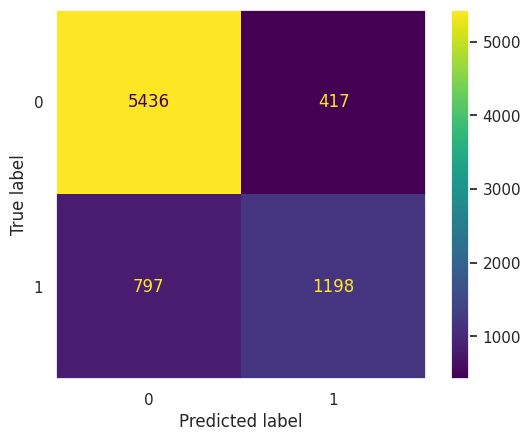

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, x_test, y_test)
plt.grid(False)

In [55]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_test, y_predicted)
recall = recall_score(y_test, y_predicted)

print(f"Precision score: {precision:.3f}")
print(f"Recall score: {recall:.3f}")

Precision score: 0.742
Recall score: 0.601


## Courbe ROC, AUC

Les valeurs prédites `y_predicted` ci-dessus ont été obtenues en seuillant les probabilités de `>50K` calculées par le modèle de régression logistique avec le seuil par defaut $t=1/2$.

$$\hat y_t (x_{new}) = \begin{cases} 1 & \mathbf{\hat P}(y=1 | x_{new}) \geq t, \\ 0 & \text{sinon.}\end{cases}$$

Or, en variant le seuil $t\in(0,1)$ il est possible que le classifieur associé ait des meilleurs scores.

La courbe ROC (Receiver Operating Characteristic) est une courbe paramétrique, paramétrée par $t \in [0,1]$. Elle représente les points $(\text{FPR}_t, \text{TPR}_t)$ pour tout seuil $t\in[0,1]$, où 

- $\text{TPR}_t$ (True positive rate) est le recall en fonction du seuil $t$ :
$$\frac{\text{TP}_t}{\text{TP}_t+\text{FN}_t}$$

- $\text{FPR}_t$ (False positive rate) est définit par le ratio suivant en fonction du seuil $t$ :
$$\frac{\text{FP}_t}{\text{FP}_t+\text{TN}_t}$$

Avec le seuil $t=1$, le classifieur prédit `<=50K` systématiquement, donc il n'y a pas de positifs et on a $\text{TP}_1 = 0$ et $\text{FP}_1 = 0$. En revanche, avec un seuil de $t=0$, le classifieur prédit toujours `>50K` et donc on a $\text{TP}_0 = 1$ et $\text{FP}_0 = 1$. Toutes les courbes ROC commencent donc au point $(0, 0)$ et se terminent au point $(1,1)$. La fonction $y=x$ represente la courbe ROC de la famille di classifieurs $\hat y_t (x_{new}) = 1$ avec probabilité $t\in(0,1)$.

Si la courbe est élevée, le modèle a une très bonne performance quelque soit le seuil. Cela est mesuré par l'aire sous la courbe (AUC -- Area Under the ROC curve). L'AUC permet de comparer deux modèles, ou un modèle sur des jeux de données différentes, comme les données train et test.

### Exercice : ROC
- Utiliser la fonction `RocCurveDisplay` pour tracer la courbe ROC de notre modèle pour les données train et les données test. Sur quelles données observe-t-on une meilleure performance ?
- Utiliser la fonction `roc_auc_score` pour calculer l'AUC sur les données de test et vérifier qu'elle correspond à l'AUC indiquée sur le tracé de courbe au point précédent.

In [58]:
from sklearn.dummy import DummyClassifier

dummy_classifier = DummyClassifier(strategy="most_frequent")
dummy_classifier.fit(x_train, y_train)
print(f"Accuracy of the dummy classifier: {dummy_classifier.score(x_test, y_test):.3f}")

Accuracy of the dummy classifier: 0.746


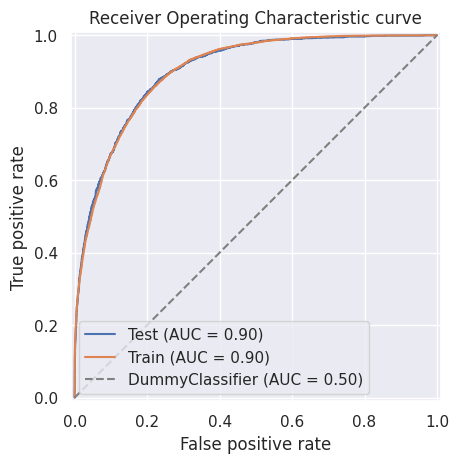

In [59]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots()
RocCurveDisplay.from_estimator(model, x_test, y_test, name="Test", ax=ax)
RocCurveDisplay.from_estimator(model, x_train, y_train, name="Train", ax=ax)
RocCurveDisplay.from_estimator(dummy_classifier, x_test, y_test, linestyle="--", color='grey', ax=ax)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Receiver Operating Characteristic curve")
ax.legend()
plt.show()

## Courbe precision/recall, AP

Un autre outil de comparaison est la courbe precision/recall qui représente les points des coordonnées (recall, precision) pour tout seuil $t\in[0,1]$. L'interprétation est la même : plus la courbe est élevée (ou plus l'aire sous la courbe est grande), mieux c'est.

Noter que contrairement à la courbe ROC, la courbe precision/recall n'est pas toujours monotone.

### Exercice : precision/recall
- Tracer la courbe precision/recall de notre modèle sur les données test en utilisant la fonction `PrecisionRecallDisplay`.


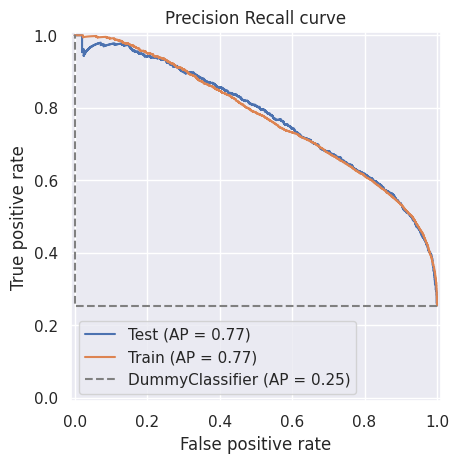

In [60]:
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots()
PrecisionRecallDisplay.from_estimator(model, x_test, y_test, name="Test", ax=ax)
PrecisionRecallDisplay.from_estimator(model, x_train, y_train, name="Train", ax=ax)
PrecisionRecallDisplay.from_estimator(dummy_classifier, x_test, y_test, linestyle="--", color='grey', ax=ax)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Precision Recall curve")
ax.legend()
plt.show()

# Régression logistique avec pénalisations

Une pénalité est une fonction $\text{pen}(w)$ qui prend des grandes valeurs pour des grandes valeurs de $w$. 

Pour éviter le phénomène du *overfitting*, nous cherchons à minimiser non plus une fonction de perte $L (w, b)$, mais une fonction de perte pénalisé :

$$ L (w, b) + \frac 1 C \; \text{pen}(w)$$

Plus la constante $C$ est petite, plus le modèle est pénalisé. Une constante $C=\infty$ correspond à une absence de pénalité.

## Régression ridge

Nous allons utiliser une pénalité en norme 2 (dite $\ell_2$ ou Ridge) sur les coefficients de la régression. 

$$\text{pen}(w) =\| w\|_2^2  = \sum_{k=1}^d w_k^2$$

Cette pénalité Ridge a tendance à "rétrecir" les valeurs des coefficients (on parle de shrinkage) et régularise la solution.

### Exercice : pénalité $\ell_2$

- Mettre en oeuvre la régression logistique avec pénalité $\ell_2$ sur les données d'apprentissage. On utilisera toujours la fonction `LogisticRegression`avec  l'option `l1_ratio=0`. On utilisera une pénalité assez forte, p. ex. `C=0.01`. 
- Comparer les valeurs des coefficients avec le cas sans pénalité (visualisez l'effet de shrinkage). 
- Évaluer les performances du classifieur sur les données de test.
- Pour les deux classifieurs (avec et sans pénalisation $\ell_2$), comparer les courbes de score sur les données `test` ainsi que les performances en termes de courbes (ROC ou precision-recall) et d'AUC. 

In [69]:
C_ridge = 0.01
model_ridge = LogisticRegression(l1_ratio=0, C=C_ridge)

model_ridge.fit(x_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mult

In [66]:
# On définit une fct pour extraire les coefficients
def extract_coeff(model, name=None):
    return pd.DataFrame({ 
        "feature": model.feature_names_in_, 
        "value": np.abs(model.coef_.flatten()), 
        "method": name, 
    })

In [67]:
extract_coeff(model, "no penality")

,feature,value,method
0,age,0.290220,no penality
1,capital-gain,2.526386,no penality
2,capital-loss,0.278953,no penality
3,hours-per-week,0.361621,no penality
4,workclass_Federal-gov,0.383947,no penality
...,...,...,...
97,native-country_Thailand,0.371696,no penality
98,native-country_Trinadad&Tobago,0.789853,no penality
99,native-country_United-States,0.394237,no penality
100,native-country_Vietnam,1.412191,no penality


In [70]:
print(f"Nombre de coefficients non nuls avec pénalité Ridge (C={C_ridge}):", np.sum(extract_coeff(model_ridge)["value"] > 0))

Nombre de coefficients non nuls avec pénalité Ridge (C=0.01): 102


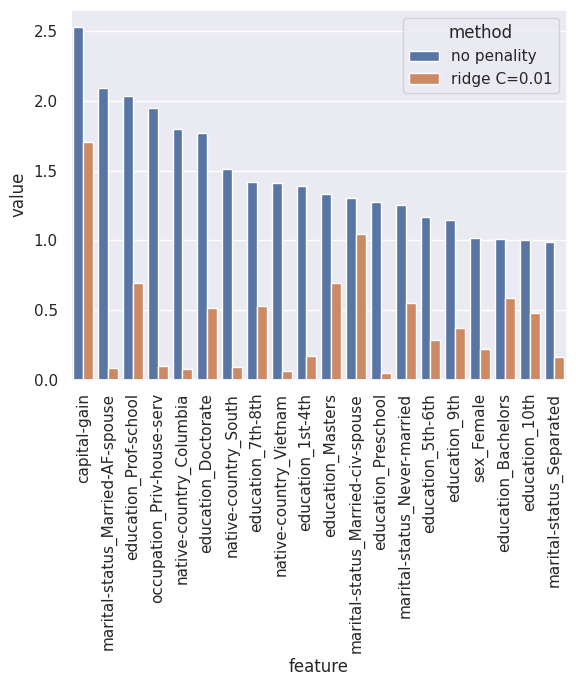

In [72]:
# On visualise l'effet de 'shrinkage'
ax = sns.barplot(data=pd.concat([df1, df2]), x="feature", y="value", hue="method")
ax.tick_params(axis='x', rotation=90)

In [74]:
df2.sort_values("value", ascending=False)[:7]

,feature,value,method
1,capital-gain,1.704012,ridge C=0.01
29,marital-status_Married-civ-spouse,1.044091,ridge C=0.01
15,education_Prof-school,0.693313,ridge C=0.01
14,education_Masters,0.691466,ridge C=0.01
11,education_Bachelors,0.581746,ridge C=0.01
31,marital-status_Never-married,0.551921,ridge C=0.01
21,education_7th-8th,0.525704,ridge C=0.01


In [75]:
df1.sort_values("value", ascending=False)[:7]

,feature,value,method
1,capital-gain,2.526386,no penality
28,marital-status_Married-AF-spouse,2.089774,no penality
15,education_Prof-school,2.035219,no penality
42,occupation_Priv-house-serv,1.951466,no penality
64,native-country_Columbia,1.796158,no penality
18,education_Doctorate,1.768664,no penality
95,native-country_South,1.510325,no penality


In [73]:
# On trie les coefficients par ordre decroissant et on selectionne les premiers 20
df1 = extract_coeff(model, "no penality").sort_values("value", ascending=False)[:20]
df2 = extract_coeff(model_ridge, f"ridge C={C_ridge}")
df2 = df2[df2["feature"].isin(df1["feature"])]

## Régression lasso

Dans cette partie, on va mettre en oeuvre une pénalité $\ell_1$ dans la régression logistique. Cela peut permettre de faire de la sélection de variables : les variables peu informatives pour la prédiction ne seront plus du tout utilisées (coefficient $w_i$ estimé à 0). On peut ainsi construire un estimateur plus parcimonieux. 

### Exercice : pénalité $\ell_1$

- Mettre en oeuvre la régression logistique avec pénalité $\ell_1$ sur les données d'apprentissage (avec l'option `solver='liblinear'`).
- Comparer les valeurs des coefficients avec le cas sans pénalité et avec pénalité $\ell_2$ (visualiser l'effet d'annulation des coefficients). Tester différentes valeurs de $C$.
- Pour l'ensemble des classifieurs (avec et sans pénalisation $\ell_1$ et $\ell_2$), comparer les performances en termes de courbes (ROC et precision-recall) et d'AUC. 

In [77]:
C_lasso = 0.01
model_lasso = LogisticRegression(C=C_lasso, l1_ratio=1, solver='liblinear')

In [79]:
model_lasso.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mult

In [86]:
np.sum(abs(model_lasso.coef_[0])>0)

np.int64(22)

In [89]:
model_lasso.coef_[0]

np.float64(0.0)

In [90]:
print(f"Nombre de coefficients non nuls avec pénalité Ridge (C={C_lasso}):", np.sum(extract_coeff(model_lasso)["value"] > 0))

Nombre de coefficients non nuls avec pénalité Ridge (C=0.01): 22


In [92]:
extract_coeff(model_lasso, "lasso")

0      0.223642
1      2.038848
2      0.262086
3      0.334502
4      0.000000
         ...   
97     0.000000
98     0.000000
99     0.000000
100    0.000000
101    0.000000
Name: value, Length: 102, dtype: float64

In [94]:
df3 = extract_coeff(model_lasso, f"lasso C={C_lasso}")
df3 = df3[df3["feature"].isin(df1["feature"])]

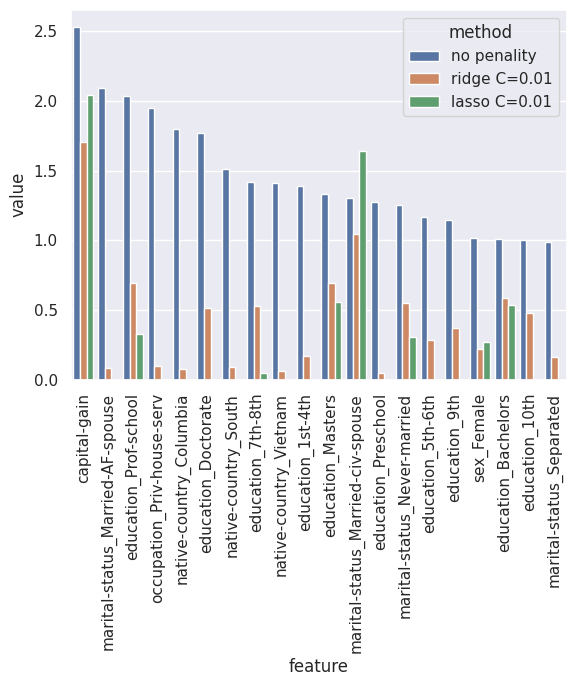

In [96]:
ax = sns.barplot(data=pd.concat([df1, df2, df3]), x="feature", y="value", hue="method")
ax.tick_params(axis='x', rotation=90)

### Chemins de régularisation pour le Lasso

Le but est de visualiser l'effet de la **constante de pénalisation** sur l'évolution des coefficients $w_i$, à travers les **chemins de régularisation**. Lorsque la pénalité est très forte (i.e $C$ très petite), aucune  variable n'est sélectionnée (tous les coefficients $w_i$ sont estimés à 0). Dans ce cas, la fonction de régression logistique est constante (on a seulement l'intercept) et le lien entre $y$ et $X$ est très mal appris. Puis au fur et à mesure que $C$ augmente, on inclue de plus en plus de variables dans notre modèle de régression logistique. Lorsque $C$ est très grande, on ne pénalise plus et on retrouve les résultats de la régression logistique simple. 

### Exercice : évolution des coéfficients en fonction de $C$

- Fixer une grille de valeurs de $C$, estimer le modèle lasso pour chaque constante $C$ et afficher les coefficients en fonction de $C$. 

In [97]:
n_grid = 13
C_grid = np.logspace(-4, 1, n_grid)

In [98]:
C_grid


array([1.00000000e-04, 2.61015722e-04, 6.81292069e-04, 1.77827941e-03,
       4.64158883e-03, 1.21152766e-02, 3.16227766e-02, 8.25404185e-02,
       2.15443469e-01, 5.62341325e-01, 1.46779927e+00, 3.83118685e+00,
       1.00000000e+01])

In [103]:
n_coef = model.coef_.shape[1]
C_grid = np.logspace(-4, 1, n_grid)
coefs = np.empty((n_grid, n_coef))
scores = np.empty(n_grid)

for k, C in enumerate(C_grid): 
    model_ = LogisticRegression(l1_ratio=1, C=C, max_iter=1000, solver='liblinear')
    model_.fit(x_train, y_train)
    score = model_.score(x_test, y_test) 
    coefs[k] = model_.coef_
    scores[k] = score

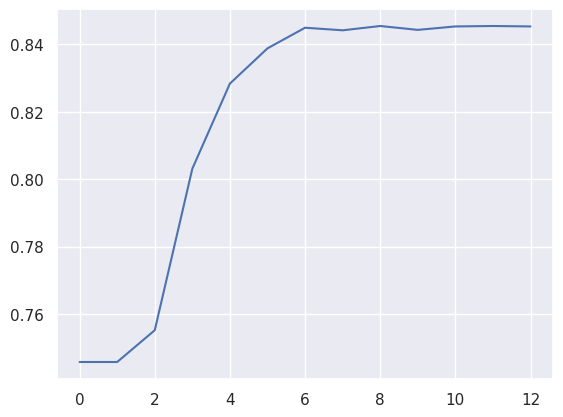

In [104]:
plt.plot(scores)

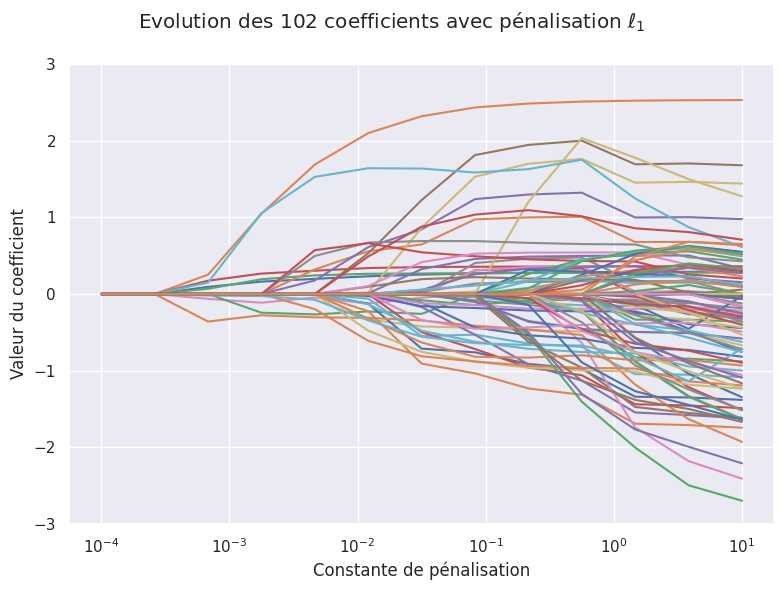

In [100]:
fig, ax = plt.subplots(figsize=(8,6), layout="tight")
ax.semilogx(C_grid, coefs)
ax.set_ylim(-3, 3)
ax.set_xlabel("Constante de pénalisation")
ax.set_ylabel("Valeur du coefficient")
fig.suptitle(fr"Evolution des {n_coef} coefficients avec pénalisation $\ell_1$")
plt.show()

# Validation croisée

La validation croisée consiste à entrainer le modèle sur différents sous-échantillons des données et d'évaluer à chaque fois sa capacité prédictive sur le reste des données. 
La validation croisée permet de choisir la meilleure constante $C$ de la pénalité Lasso ou Ridge. Plus généralement, dans de nombreux autres modèles, la validation croisée est utilisée pour ajuster les hyperparamètres du modèle de façon optimale en évitant le surapprentissage et augmentant sa capacité de généralisation sur des nouvelles données.

## Exercice :  Stabilité des prédictions

- Utiliser la fonction `cross_validate` du module `sklearn.model_selection` pour obtenir un intervale de confiance de l'accuracy score. On fera cette étude sur le modèle de régression logistique simple `model` et celui avec pénalité $\ell_1$ `model_lasso`.

In [101]:
%%time
from sklearn.model_selection import cross_validate

cv_results = cross_validate(model, standard_data, labels, cv=8)
cv_results

CPU times: user 2min 30s, sys: 239 ms, total: 2min 31s
Wall time: 19.8 s


{'fit_time': array([2.47647762, 2.11274576, 2.27787614, 2.78816175, 2.64831519,
        2.69735289, 2.06506276, 2.49259734]),
 'score_time': array([0.01451659, 0.01058555, 0.01369047, 0.03512859, 0.03497481,
        0.02225161, 0.02225375, 0.02277946]),
 'test_score': array([0.83710499, 0.84444444, 0.84138634, 0.84342508, 0.84689093,
        0.83649337, 0.84057085, 0.84077472])}

In [105]:
scores = cv_results["test_score"]
print("The mean cross-validation accuracy is: "
      f"{scores.mean():.3f} ± {scores.std():.3f}")

The mean cross-validation accuracy is: 0.841 ± 0.003


## Choix de la constante de pénalisation

On peut aussi utiliser la validation croisée pour choisir un hyperparamètre. Dans cette partie, nous allons mettre en oeuvre le choix de la constante de pénalisation par **validation croisée**. 
Nous le ferons dans le cadre d'une pénalité $\ell_1$, mais on pourrait faire exactement la même chose avec un autre type de pénalité. 

Par défaut, la fonction `LogisticRegression` ne sait pas choisir la constante de pénalisation automatiquement et par défaut cette constante est fixée à 1. Ce choix n'a pas de justification et n'a donc aucune raison d'être utilisé. 

## Exercice : validation croisée

- Utiliser la fonction `LogisticRegressionCV` pour choisir la constante $C$ qui maximise le score AUC (aire sous la courbe ROC) dans une grille de valeur de $C$ fixée.

In [106]:
%%time
from sklearn.linear_model import LogisticRegressionCV

C_grid = np.logspace(-4, 1, 14)
cv = 8

# Modèle de régression logistique avec pénalité l1 
# validation croisée pour le choix automatique de la constante de pénalité C
model_lasso_cv = LogisticRegressionCV(penalty='l1', tol=1e-3, Cs=C_grid, cv=8,
                                      solver='liblinear', scoring='roc_auc') 
model_lasso_cv.fit(x_train, y_train)

# résultats intermédiaires de calculs de ROC-AUC sur chacun des cv-folds
crit = model_lasso_cv.scores_[1]
print(crit)

[[0.5        0.5        0.7826097  0.85229244 0.87210847 0.88298616
  0.89305498 0.89707044 0.8985095  0.8994594  0.89996124 0.89978305
  0.89963365 0.89947053]
 [0.5        0.5        0.79785462 0.85907055 0.87690352 0.88614408
  0.89557603 0.89997135 0.90126975 0.90182522 0.90206098 0.90200958
  0.9019407  0.90182762]
 [0.5        0.5        0.7828996  0.85128292 0.87105406 0.88254908
  0.8947591  0.8997272  0.90096357 0.90205413 0.90252873 0.90241736
  0.90234814 0.90227378]
 [0.5        0.5        0.78400627 0.8483743  0.86654925 0.87904815
  0.89207784 0.89733773 0.8988006  0.89947345 0.89956014 0.89949606
  0.89934152 0.8990732 ]
 [0.5        0.5        0.7702125  0.84634169 0.86482963 0.87435534
  0.88628179 0.89054014 0.89219673 0.8926801  0.89275064 0.89266229
  0.892476   0.89241128]
 [0.5        0.5        0.80054316 0.86379526 0.88171952 0.88892909
  0.89819061 0.90180874 0.90231488 0.90240563 0.90284756 0.90301536
  0.90303967 0.90294653]
 [0.5        0.5        0.79733048

In [116]:
model_lasso_cv.C_[0]

np.float64(0.701703828670383)

In [117]:
model_lasso_best_C = LogisticRegression(l1_ratio=1, C=model_lasso_cv.C_[0], solver="liblinear")

In [118]:
model_lasso_best_C.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",np.float64(0.701703828670383)
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of p

In [120]:
model_lasso_best_C.score(x_test,y_test)

0.8448012232415902

In [127]:
pred_proba = model_lasso_best_C.predict_proba(x_test)[:,1]

In [128]:
pred_proba

array([0.25859468, 0.14880563, 0.15206045, ..., 0.71794228, 0.38578253,
       0.39112271], shape=(7848,))

In [130]:
metrics.roc_auc_score( y_test, pred_proba)

0.903113969786931

In [ ]:
?metrics.

# `scikit-learn` et automatisation: `pipeline`

En `scikit-learn`, un _pipeline_ est une séquence ordonnée d'étapes de prétraitement des données et de modélisation regroupées en une seule entité. Il permet de définir et d'automatiser un flux de travail cohérent pour le traitement des données et l'entraînement d'un modèle.

Il se compose en général de plusieurs étapes:
- transformations des données :  normalisation des variables, l'imputation des valeurs manquantes, la réduction de dimension, etc. Elles permettent de préparer les données avant de les fournir au modèle.
- le modèle d'apprentissage automatique.
- la validation croisée : pour évaluer les performances du modèle.

L'avantage d'utiliser un pipeline est qu'il permet de regrouper toutes ces étapes en une seule entité. 

## Exercice : Création d'un pipeline pour notre régression logistique 

- Définir à partir des classes `OneHotEncoder`, `StandardScaler` de `sklearn.preprocessing` et `ColumnTransformer` de `sklearn.compose` un préprocesseur qui réalise les mêmes transformations que celles faites dans la section 1.1.5 (Pré-traitement des données). Attention, la transformation `OneHotEncoder` doit s'appliquer uniquement aux données qualitatives et la transformation `StandardScaler` doit s'appliquer uniquement aux données quantitatives. 
- Créer un pipeline avec la fonction `make_pipeline` de `sklearn.pipeline` pour définir un modèle de régression logistique avec prétraitement des données automatique (fait par le préprocesseur).

## Exercice : Utilisation du pipeline 

- Faire une estimation du modèle. Attention, quelles données doivent être utilisées ?
- Faire des prédictions et calculer les différents scores sur le jeu de test.
- Faire une étape de validation croisée. 

## Exercice : Avec une autre méthode de classification : Gradient Boosting

L'avantage d'utiliser un module riche comme `scikit-learn` est qu'on peut facilement changer une brique pour tester d'autres modèles. Ici on propose de remplacer la brique `LogisticRegression` par une méthode basée sur les arbres de décisions. Les arbres de décisions et les méthodes de "boosting" seront expliquées dans le second cours mais voyons les résultats que l'on peut obtenir. 

- Utiliser le préprocesseur `OneHotEncoder` avec l'option `sparse_output` à `False` et la classe `HistGradientBoostingClassifier` du module `sklearn.ensemble` pour composer un pipeline que l'on nomme `model_gradboost`.

- Comparer les courbes ROC et Precision/Recall obtenues avec cet estimateur et la régression logistique. 